In [5]:
# SimPEG нашёл этот пакет для работы с различными геофизическими задачами https://simpeg.xyz/
import simpeg.electromagnetics.time_domain as tdem
from simpeg import maps
from simpeg.utils import plot_1d_layer_model

import os
import numpy as np
from scipy.constants import mu_0
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.special import erf

In [6]:
# Параметры модели
rho_b = 1.0      # скважина (Ом·м)
rho_iz = 30.0    # зона проникновения (Ом·м)
rho_f = 10.0     # пласт (Ом·м)
r_b = 0.1        # радиус скважины (м)
r_iz = 0.5       # радиус зоны проникновения (м)

model = (rho_b, rho_iz, rho_f, r_b, r_iz)

In [7]:
def forward_step(model, L):
    """Исходная модель с резкими границами."""
    rho_b, rho_iz, rho_f, r_b, r_iz = model

    if L <= r_b:
        return rho_b
    elif L <= r_iz:
        sigma_eff = (r_b**2 / rho_b + (L**2 - r_b**2) / rho_iz) / L**2
        return 1.0 / sigma_eff
    else:
        sigma_eff = (r_b**2 / rho_b + (r_iz**2 - r_b**2) / rho_iz +
                     (L**2 - r_iz**2) / rho_f) / L**2
        return 1.0 / sigma_eff

def forward_smooth(model, L, sigma=0.5):
    """Гладкая модель с функцией ошибок."""
    rho_b, rho_iz, rho_f, r_b, r_iz = model

    logL = np.log(L)
    log_rb = np.log(r_b)
    log_riz = np.log(r_iz)

    w_b = 0.5 * (1 - erf((logL - log_rb) / (sigma * np.sqrt(2))))
    w_iz = 0.5 * (erf((logL - log_rb) / (sigma * np.sqrt(2))) -
                  erf((logL - log_riz) / (sigma * np.sqrt(2))))
    w_f = 0.5 * (1 + erf((logL - log_riz) / (sigma * np.sqrt(2))))

    sigma_eff = w_b / rho_b + w_iz / rho_iz + w_f / rho_f
    return 1.0 / sigma_eff if sigma_eff > 0 else np.inf

In [8]:
# Преобразование в начальные условия для 1D TDEM
def get_initial_conditions(model, smooth=True, sigma=0.5):
    """Подготовка начальных условий для TDEM инверсии."""
    rho_b, rho_iz, rho_f, r_b, r_iz = model
    
    # Толщины слоёв (м)
    thicknesses = [r_b, r_iz - r_b, 100.0]  # последний слой - полупространство
    
    # УЭС слоёв (Ом·м)
    if smooth:
        # Для гладкой модели используем средние значения
        resistivities = [rho_b, rho_iz, rho_f]
    else:
        resistivities = [rho_b, rho_iz, rho_f]
    
    return {
        'thicknesses': thicknesses,
        'resistivities': resistivities,
        'model': model,
        'smooth': smooth,
        'sigma': sigma
    }

# Создаём начальные условия
initial_conditions = get_initial_conditions(model, smooth=True, sigma=0.5)

print("Начальные условия готовы:")
print(f"Толщины слоёв: {initial_conditions['thicknesses']} м")
print(f"УЭС слоёв: {initial_conditions['resistivities']} Ом·м")

Начальные условия готовы:
Толщины слоёв: [0.1, 0.4, 100.0] м
УЭС слоёв: [1.0, 30.0, 10.0] Ом·м


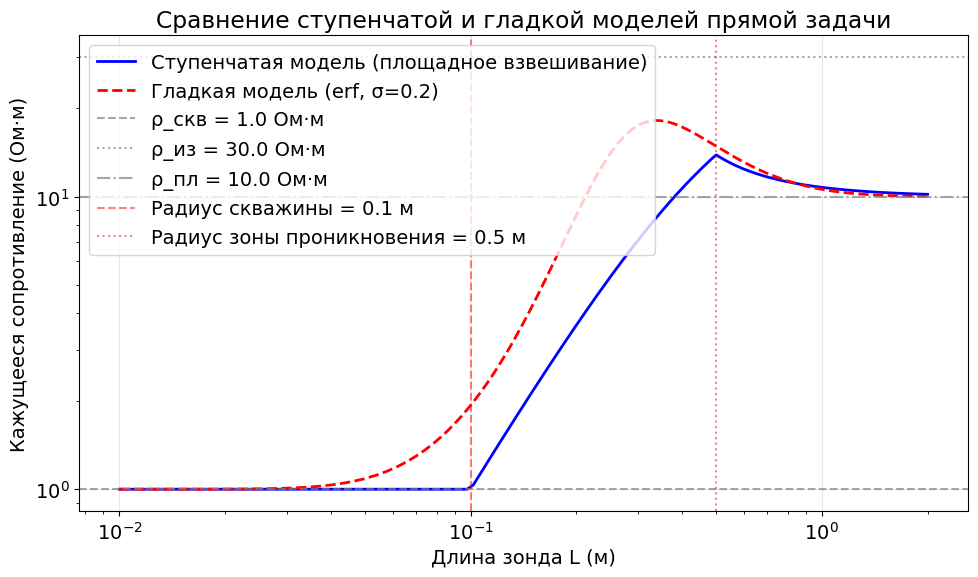

Stored 'initial_conditions' (dict)
Stored 'model' (tuple)


In [10]:
# Проверка forward-моделей
L_values = np.linspace(0.01, 2.0, 500)

rho_step = np.array([forward_step(model, L) for L in L_values])
rho_smooth = np.array([forward_smooth(model, L, sigma=0.5) for L in L_values])

plt.figure(figsize=(10, 6))

# Ступенчатая модель
plt.plot(L_values, rho_step, 'b-', linewidth=2, label='Ступенчатая модель (площадное взвешивание)')

# Гладкая модель
plt.plot(L_values, rho_smooth, 'r--', linewidth=2, label=f'Гладкая модель (erf, σ={0.2})')

# Истинные сопротивления слоёв
plt.axhline(y=rho_b, color='gray', linestyle='--', alpha=0.7, label=f'ρ_скв = {rho_b} Ом·м')
plt.axhline(y=rho_iz, color='gray', linestyle=':', alpha=0.7, label=f'ρ_из = {rho_iz} Ом·м')
plt.axhline(y=rho_f, color='gray', linestyle='-.', alpha=0.7, label=f'ρ_пл = {rho_f} Ом·м')

# Границы радиусов
plt.axvline(x=r_b, color='red', linestyle='--', alpha=0.5, label=f'Радиус скважины = {r_b} м')
plt.axvline(x=r_iz, color='red', linestyle=':', alpha=0.5, label=f'Радиус зоны проникновения = {r_iz} м')

plt.xlabel('Длина зонда L (м)')
plt.ylabel('Кажущееся сопротивление (Ом·м)')
plt.title('Сравнение ступенчатой и гладкой моделей прямой задачи')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.show()
# Сохранение для использования в других ячейках
%store initial_conditions
%store model

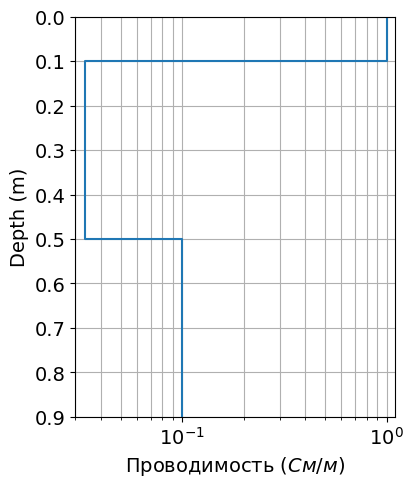

In [13]:
mpl.rcParams.update({"font.size": 14})

write_output = False  

rho_b = 1.0      # скважина (Ом·м)
rho_iz = 30.0    # зона проникновения (Ом·м)
rho_f = 10.0     # пласт (Ом·м)
r_b = 0.1        # радиус скважины (м)
r_iz = 0.5       # радиус зоны проникновения (м)

# Преобразование в проводимость (См/м)
sigma_b = 1.0 / rho_b
sigma_iz = 1.0 / rho_iz
sigma_f = 1.0 / rho_f

# свойства источника
source_location = np.array([0.0, 0.0, 0.1]) 
source_orientation = "z"  
source_current = 10.0  # максимальная сила тока (A)
source_radius = 0.1  # радиус источника (м)

# свойства приёмника
receiver_locations = np.array([0.0, 0.0, 0.1]) 
receiver_orientation = "z"
times = np.logspace(-5, -2, 31)  

stepoff_waveform = tdem.sources.StepOffWaveform(off_time=1.0) #можно менять форму волны

# список приёмников (по одному на каждый источник)
receiver_list = []
receiver_list.append( tdem.receivers.PointMagneticFluxDensity( receiver_locations, times, orientation=receiver_orientation)) 

# источник (список источников, у нас один)
source_list = [
    tdem.sources.CircularLoop(
        receiver_list=receiver_list,
        location=source_location,
        orientation=source_orientation,
        waveform=stepoff_waveform,
        current=source_current,
        radius=source_radius,
    )
]

survey = tdem.Survey(source_list)

# проводимость слоёв
layer_conductivities = np.r_[sigma_b, sigma_iz, sigma_f]
layer_thicknesses = np.r_[r_b, r_iz - r_b]

# количество слоёв
n_layers = len(layer_conductivities)

fig = plt.figure(figsize=(4, 5))
ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax1 = plot_1d_layer_model(layer_thicknesses, layer_conductivities, scale="log", ax=ax1)
ax1.grid(which="both")
ax1.set_xlabel(r"Проводимость ($См/м$)")
plt.show()

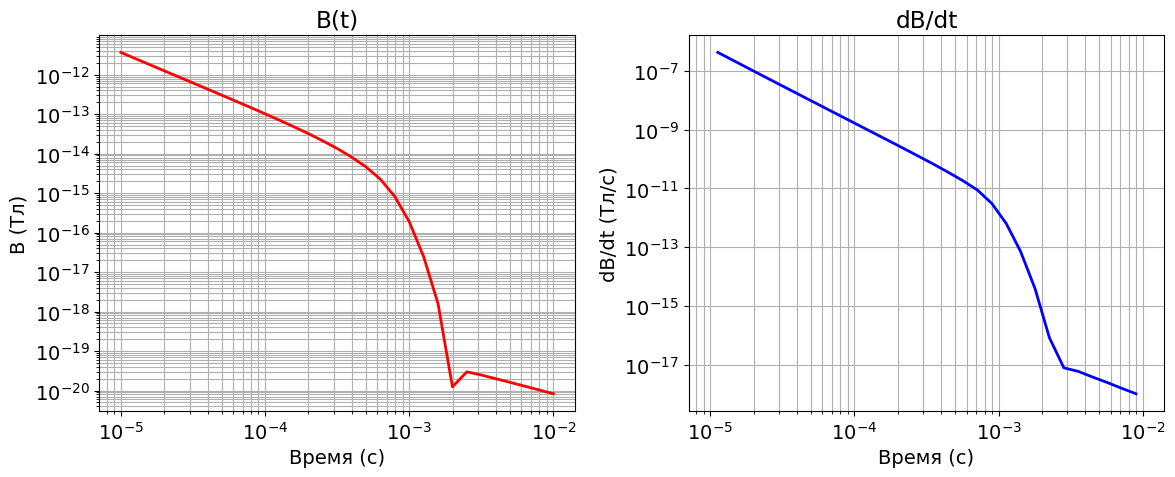

In [14]:
parametric_model = np.r_[layer_thicknesses, np.log(1 / layer_conductivities)]
wire_map = maps.Wires(("thicknesses", n_layers - 1), ("log_resistivity", n_layers))
thicknesses_map = wire_map.thicknesses
log_resistivity_map = maps.ExpMap() * wire_map.log_resistivity

simulation_parametric = tdem.simulation_1d.Simulation1DLayered(
    survey=survey,
    rhoMap=log_resistivity_map,
    thicknessesMap=thicknesses_map,
)

dpred_parametric = simulation_parametric.dpred(parametric_model)

dbdt_numerical = np.diff(dpred_parametric) / np.diff(times) #численная производная
times_mid = 0.5 * (times[:-1] + times[1:])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

axes[0].loglog(times, np.abs(dpred_parametric), "r-", lw=2)
axes[0].set_title("B(t)")
axes[0].set_xlabel("Время (с)")
axes[0].set_ylabel("B (Тл)")
axes[0].grid(True, which="both")

axes[1].loglog(times_mid, np.abs(dbdt_numerical), "b-", lw=2)
axes[1].set_title("dB/dt")
axes[1].set_xlabel("Время (с)")
axes[1].set_ylabel("dB/dt (Тл/с)")
axes[1].grid(True, which="both")

plt.tight_layout()
plt.show()

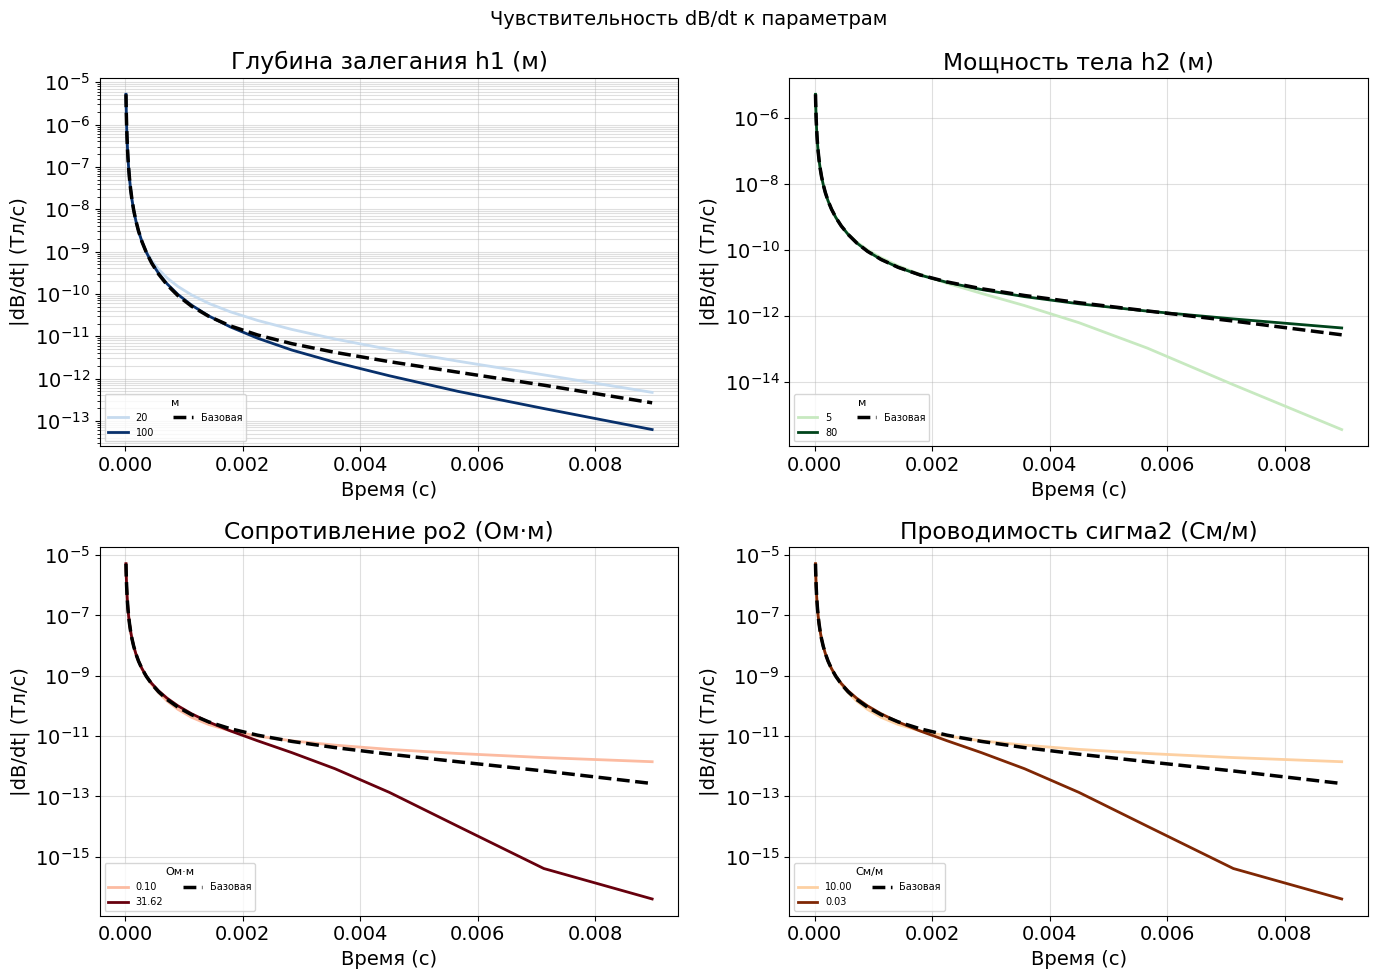

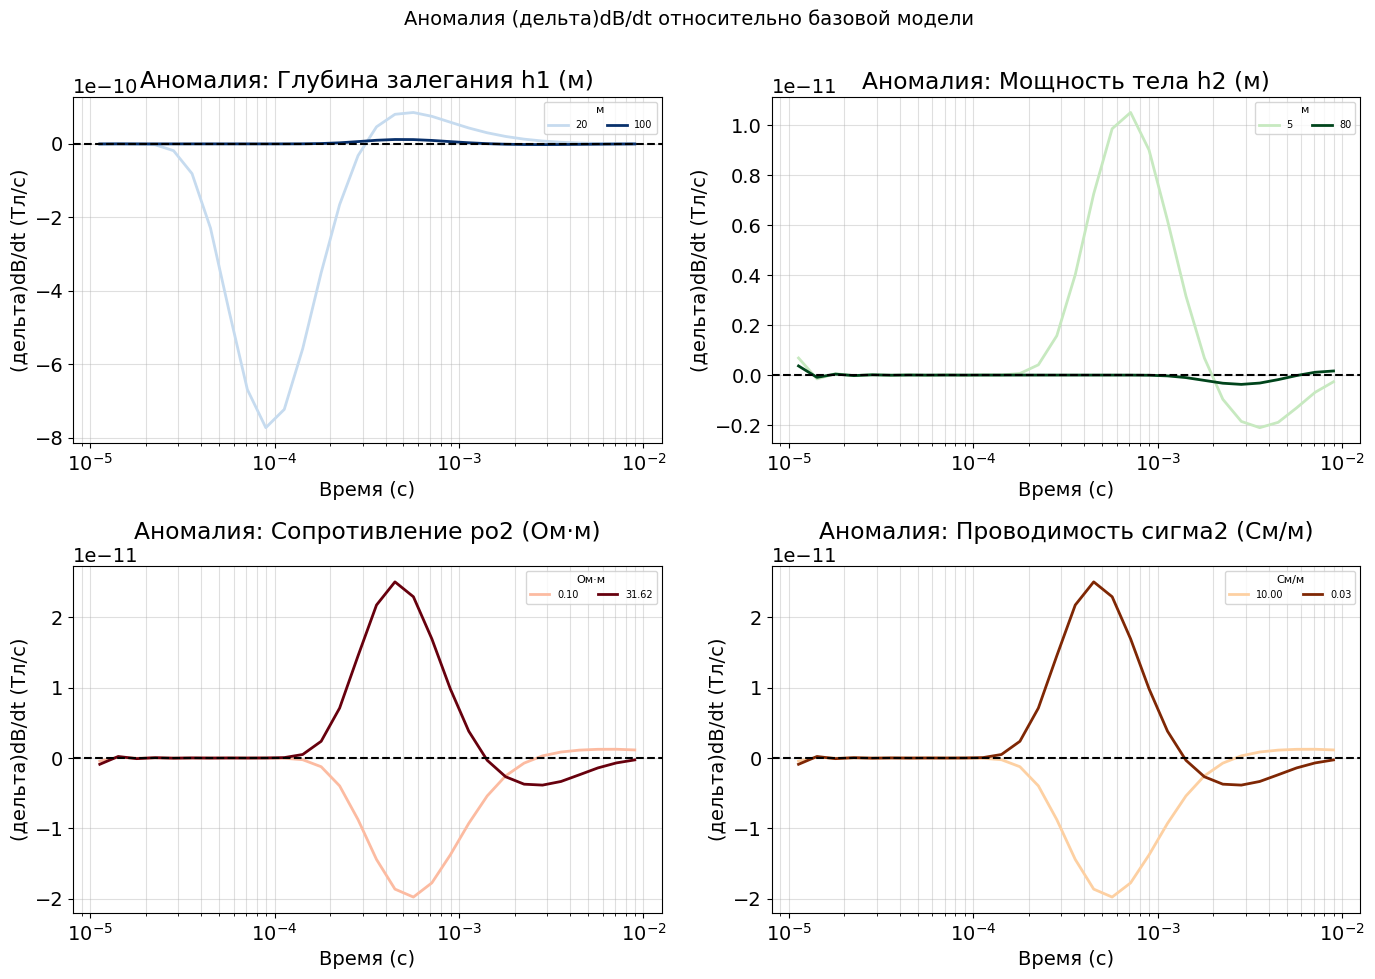

In [15]:
#тестовая (наземная)

def make_model(h1, h2, rho1, rho2, rho3):
    return np.r_[h1, h2, np.log(rho1), np.log(rho2), np.log(rho3)]

def compute_dbdt(model_vec):
    b = simulation_parametric.dpred(model_vec)
    dbdt = np.diff(b) / np.diff(times)
    return dbdt

h1_base   = 46.0       # глубина залегания рудного тела (м)
h2_base   = 40.0       # мощность рудного тела (м)
rho1_base = 1 / 0.6    # ро 1 Ом·м
rho2_base = 1 / 1.9    # ро 2 Ом·м  
rho3_base = 1 / 0.1    # ро 3 Ом·м

dbdt_base = compute_dbdt(make_model(h1_base, h2_base, rho1_base, rho2_base, rho3_base))

n_curves = 2 # количество значений отличающихся от базового

depth_range = np.linspace(20, 100, n_curves)        # глубина залегания (м)
thick_range = np.linspace(5,  80,  n_curves)        # мощность тела (м)
rho_range   = np.logspace(-1, 1.5, n_curves)        # ро от 0.1 до ~30 Ом·м
sigma_range = 1.0 / rho_range                       # сигма = 1/ро

def sweep(vary, values):
    curves = []
    for v in values:
        if vary == "depth":
            m = make_model(v, h2_base, rho1_base, rho2_base, rho3_base)
        elif vary == "thickness":
            m = make_model(h1_base, v, rho1_base, rho2_base, rho3_base)
        elif vary == "rho":
            m = make_model(h1_base, h2_base, rho1_base, v, rho3_base)
        curves.append(compute_dbdt(m))
    return curves

curves_depth = sweep("depth", depth_range)
curves_thick = sweep("thickness", thick_range)
curves_rho   = sweep("rho", rho_range)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

configs = [
    (curves_depth, depth_range, plt.cm.Blues,
     "Глубина залегания h1 (м)", "м", False),
    (curves_thick, thick_range, plt.cm.Greens,
     "Мощность тела h2 (м)", "м", False),
    (curves_rho,   rho_range,   plt.cm.Reds,
     "Сопротивление ро2 (Ом·м)", "Ом·м", True),  
    (curves_rho,   sigma_range, plt.cm.Oranges,
     "Проводимость сигма2 (См/м)", "См/м", True),]

for idx, (curves, param_vals, cmap, title, unit, is_log) in enumerate(configs):
    ax = axes[idx]
    n = len(param_vals)

    for i, (curve, val) in enumerate(zip(curves, param_vals)):
        color = cmap(0.25 + 0.75 * i / (n - 1))
        label = f"{val:.2f}" if is_log else f"{val:.0f}"
        ax.semilogy(times_mid, np.abs(curve), color=color, lw=2, label=label)

    # базовая кривая
    ax.semilogy(times_mid, np.abs(dbdt_base), "k--", lw=2.5, label="Базовая")

    ax.set_xlabel("Время (с)")
    ax.set_ylabel("|dB/dt| (Тл/с)")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.4)
    ax.legend(title=unit, fontsize=7, title_fontsize=8,
              loc="lower left", ncol=2)

plt.suptitle("Чувствительность dB/dt к параметрам", fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (curves, param_vals, cmap, title, unit, is_log) in enumerate(configs):
    ax = axes[idx]
    n = len(param_vals)

    for i, (curve, val) in enumerate(zip(curves, param_vals)):
        color = cmap(0.25 + 0.75 * i / (n - 1))
        label = f"{val:.2f}" if is_log else f"{val:.0f}"
        delta = np.abs(curve) - np.abs(dbdt_base)   # аномалия
        ax.semilogx(times_mid, delta, color=color, lw=2, label=label)

    ax.axhline(0, color="k", lw=1.5, linestyle="--")
    ax.set_xlabel("Время (с)")
    ax.set_ylabel("(дельта)dB/dt (Тл/с)")
    ax.set_title(f"Аномалия: {title}")
    ax.grid(True, which="both", alpha=0.4)
    ax.legend(title=unit, fontsize=7, title_fontsize=8,
              loc="upper right", ncol=2)

plt.suptitle("Аномалия (дельта)dB/dt относительно базовой модели", fontsize=14)
plt.tight_layout()
plt.show()

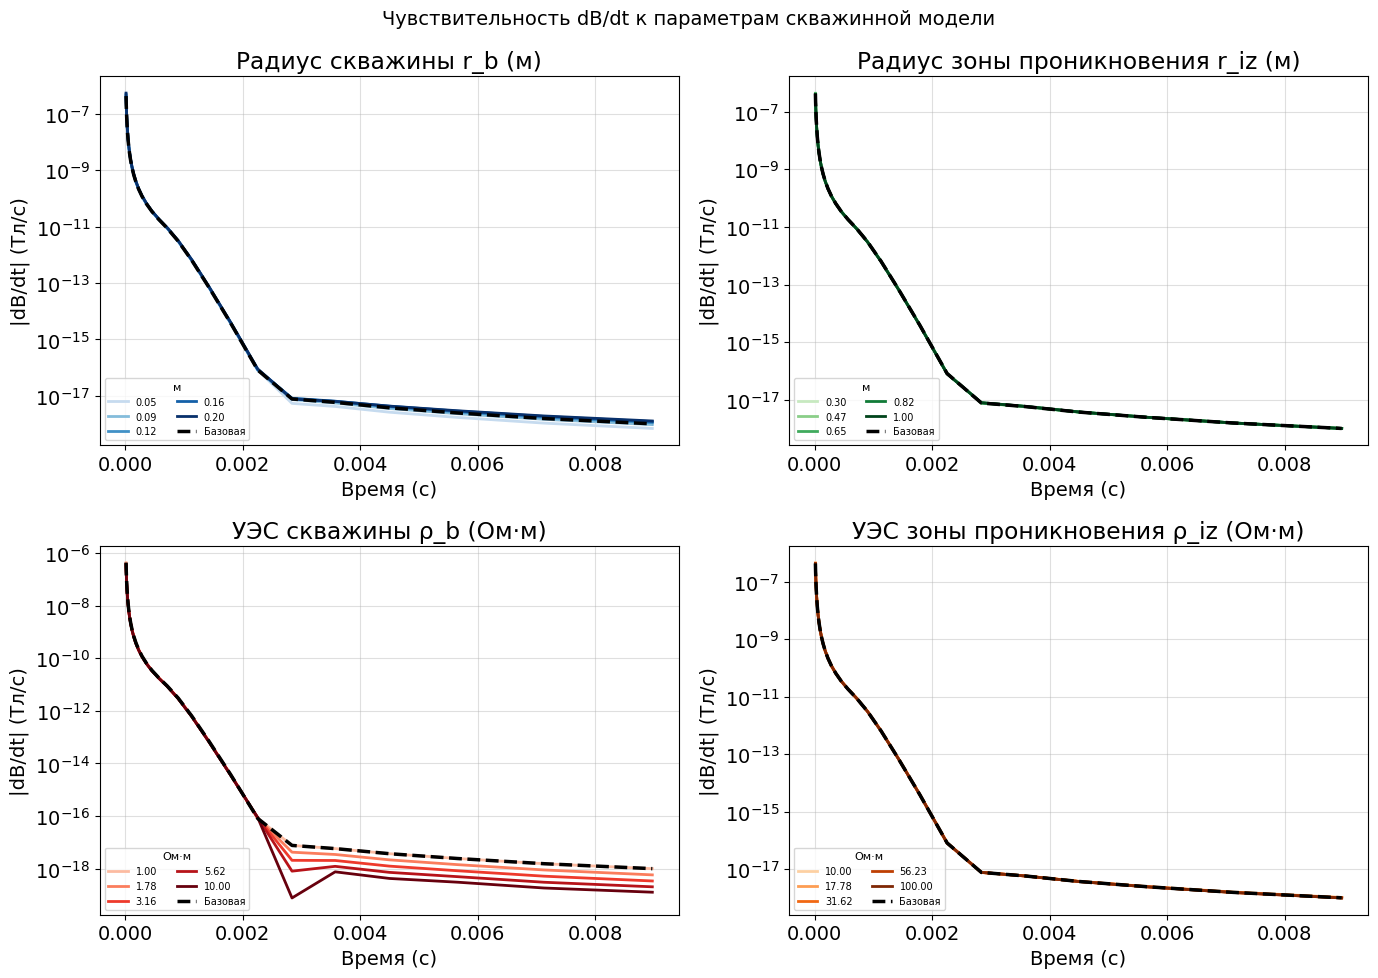

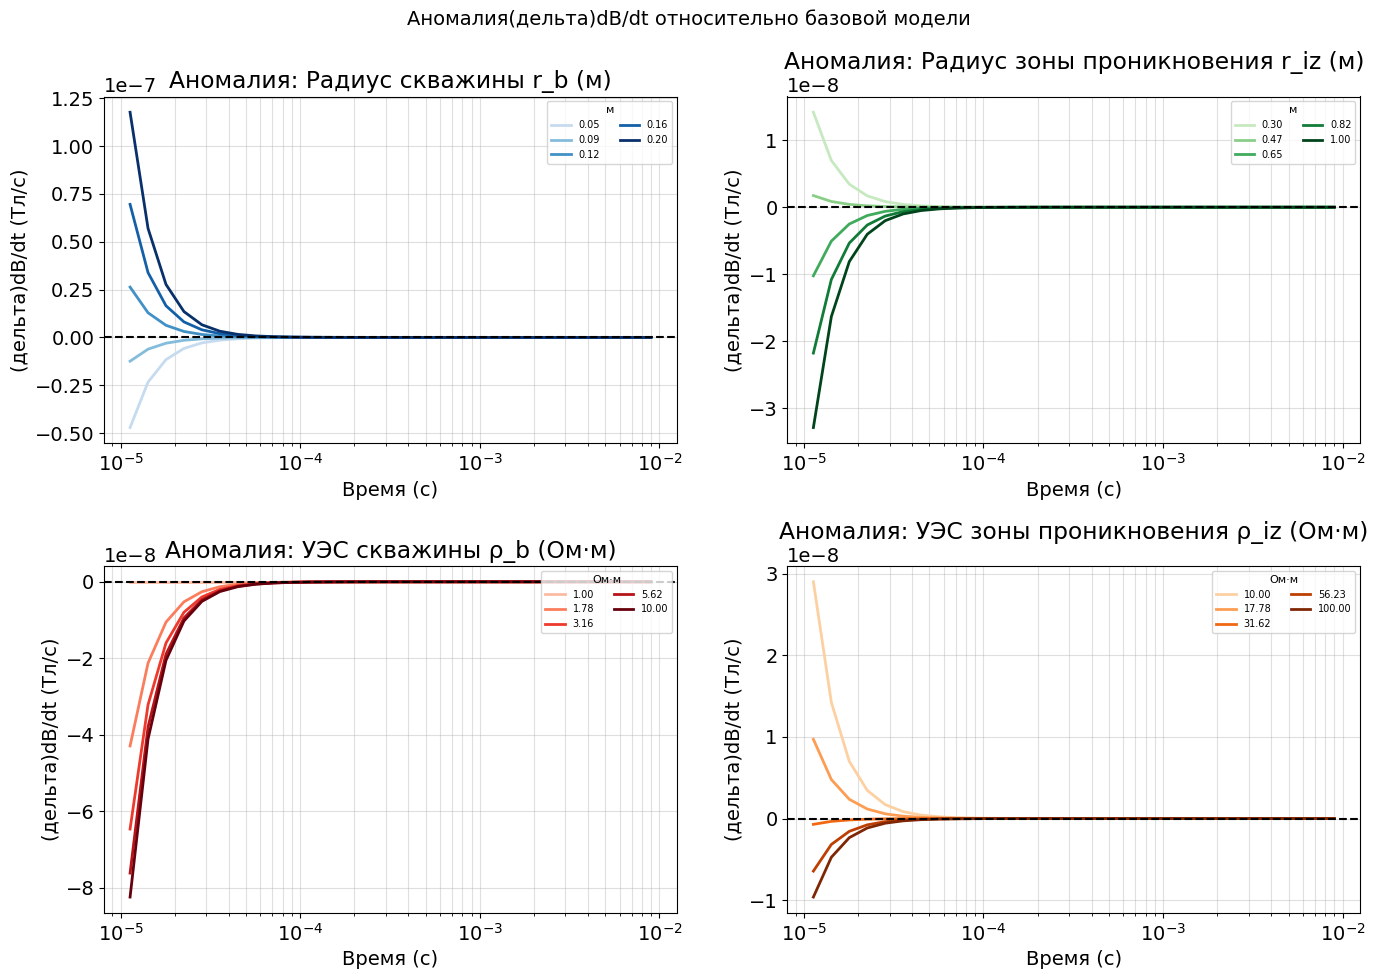

In [17]:
def make_model(r_b, r_iz, rho_b, rho_iz, rho_f):
    return np.r_[r_b, r_iz - r_b, np.log(rho_b), np.log(rho_iz), np.log(rho_f)]

def compute_dbdt(model_vec):
    b = simulation_parametric.dpred(model_vec)
    dbdt = np.diff(b) / np.diff(times)
    return dbdt


r_b_base   = 0.1        # радиус скважины (м)
r_iz_base  = 0.5        # радиус зоны проникновения (м)
rho_b_base = 1.0        # УЭС скважины (Ом·м)
rho_iz_base = 30.0      # УЭС зоны проникновения (Ом·м)
rho_f_base = 10.0       # УЭС пласта (Ом·м)

# Базовый отклик
model_base = make_model(r_b_base, r_iz_base, rho_b_base, rho_iz_base, rho_f_base)
dbdt_base = compute_dbdt(model_base)


n_curves = 5  # количество кривых для каждого параметра

# Диапазоны варьирования параметров
r_b_range   = np.linspace(0.05, 0.2, n_curves)      # радиус скважины (м)
r_iz_range  = np.linspace(0.3, 1.0, n_curves)       # радиус зоны проникновения (м)
rho_b_range = np.logspace(0, 1, n_curves)           # УЭС скважины (Ом·м)
rho_iz_range = np.logspace(1, 2, n_curves)          # УЭС зоны проникновения (Ом·м)

def sweep(vary, values):
    curves = []
    for v in values:
        if vary == "r_b":
            m = make_model(v, r_iz_base, rho_b_base, rho_iz_base, rho_f_base)
        elif vary == "r_iz":
            m = make_model(r_b_base, v, rho_b_base, rho_iz_base, rho_f_base)
        elif vary == "rho_b":
            m = make_model(r_b_base, r_iz_base, v, rho_iz_base, rho_f_base)
        elif vary == "rho_iz":
            m = make_model(r_b_base, r_iz_base, rho_b_base, v, rho_f_base)
        curves.append(compute_dbdt(m))
    return curves

# Генерация кривых
curves_r_b   = sweep("r_b", r_b_range)
curves_r_iz  = sweep("r_iz", r_iz_range)
curves_rho_b = sweep("rho_b", rho_b_range)
curves_rho_iz = sweep("rho_iz", rho_iz_range)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

configs = [
    (curves_r_b, r_b_range, plt.cm.Blues,
     "Радиус скважины r_b (м)", "м", False),
    (curves_r_iz, r_iz_range, plt.cm.Greens,
     "Радиус зоны проникновения r_iz (м)", "м", False),
    (curves_rho_b, rho_b_range, plt.cm.Reds,
     "УЭС скважины ρ_b (Ом·м)", "Ом·м", True),
    (curves_rho_iz, rho_iz_range, plt.cm.Oranges,
     "УЭС зоны проникновения ρ_iz (Ом·м)", "Ом·м", True),
]

for idx, (curves, param_vals, cmap, title, unit, is_log) in enumerate(configs):
    ax = axes[idx]
    n = len(param_vals)

    for i, (curve, val) in enumerate(zip(curves, param_vals)):
        color = cmap(0.25 + 0.75 * i / (n - 1))
        label = f"{val:.2f}" if is_log else f"{val:.2f}"
        ax.semilogy(times_mid, np.abs(curve), color=color, lw=2, label=label)

    # Базовая кривая
    ax.semilogy(times_mid, np.abs(dbdt_base), "k--", lw=2.5, label="Базовая")

    ax.set_xlabel("Время (с)")
    ax.set_ylabel("|dB/dt| (Тл/с)")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.4)
    ax.legend(title=unit, fontsize=7, title_fontsize=8,
              loc="lower left", ncol=2)

plt.suptitle("Чувствительность dB/dt к параметрам скважинной модели", fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (curves, param_vals, cmap, title, unit, is_log) in enumerate(configs):
    ax = axes[idx]
    n = len(param_vals)

    for i, (curve, val) in enumerate(zip(curves, param_vals)):
        color = cmap(0.25 + 0.75 * i / (n - 1))
        label = f"{val:.2f}" if is_log else f"{val:.2f}"
        delta = np.abs(curve) - np.abs(dbdt_base)  # аномалия
        ax.semilogx(times_mid, delta, color=color, lw=2, label=label)

    ax.axhline(0, color="k", lw=1.5, linestyle="--")
    ax.set_xlabel("Время (с)")
    ax.set_ylabel("(дельта)dB/dt (Тл/с)")
    ax.set_title(f"Аномалия: {title}")
    ax.grid(True, which="both", alpha=0.4)
    ax.legend(title=unit, fontsize=7, title_fontsize=8,
              loc="upper right", ncol=2)

plt.suptitle("Аномалия(дельта)dB/dt относительно базовой модели", fontsize=14)
plt.tight_layout()
plt.show()